# **Introduction to NLP**

## **What is NLP?**

Natural Language Processing (NLP) is a branch of Artificial Intelligence that can manipulate human language or data that resembles human language, in the way that it is written, spoken, and organized.

From chatbots to translation apps, sentiment analysis, and speech recognition — NLP powers it all.

![IMDB](https://www.blumeglobal.com/media/wp-content/uploads/2018/11/NLP-image-scaled.jpg?width=800&v=1da48718886f060)

## **Working of NLP**

**1.Text Acquisition**

This is the first step where text data is collected from sources such as:

Documents, articles, social media posts, or chats

Speech converted into text using ASR (Automatic Speech Recognition)

**2.Text Preprocessing**

Raw text is messy — it contains punctuation, capitalization, special characters, and irrelevant words.

Hence, preprocessing is done to clean and standardize it.

**3.Feature Extraction (Text Representation)**

Machines don’t understand text — they understand numbers.

So, the next step is to represent words as numerical features.

**4.Model Training**

Now the text features are fed into machine learning or deep learning models, depending on the task.

**5.Evaluation & Output**

Finally, the model’s performance is evaluated using metrics like:

**Accuracy, Precision, Recall, F1-score** (for classification tasks)

**BLEU Score** (for translation tasks)

**ROUGE Score** (for summarization)

# **Installing Necessary Dependencies**

In [ ]:
!pip install nltk pandas matplotlib seaborn


--- Logging error ---
Traceback (most recent call last):
  File "/usr/local/lib/python3.8/dist-packages/pip/_internal/utils/logging.py", line 177, in emit
    self.console.print(renderable, overflow="ignore", crop=False, style=style)
  File "/usr/local/lib/python3.8/dist-packages/pip/_vendor/rich/console.py", line 1752, in print
    extend(render(renderable, render_options))
  File "/usr/local/lib/python3.8/dist-packages/pip/_vendor/rich/console.py", line 1390, in render
    for render_output in iter_render:
  File "/usr/local/lib/python3.8/dist-packages/pip/_internal/utils/logging.py", line 134, in __rich_console__
    for line in lines:
  File "/usr/local/lib/python3.8/dist-packages/pip/_vendor/rich/segment.py", line 245, in split_lines
    for segment in segments:
  File "/usr/local/lib/python3.8/dist-packages/pip/_vendor/rich/console.py", line 1368, in render
    renderable = rich_cast(renderable)
  File "/usr/local/lib/python3.8/dist-packages/pip/_vendor/rich/protocol.py", line 36

# **Importing Dependencies**


In [ ]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import string
import re
# Download NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer,PorterStemmer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


# **Creating a  File with Text**

In [ ]:
!touch Sample.txt

!echo "Natural language processing (NLP) is the discipline of building machines that can manipulate human language — or data that resembles human language — in the way that it is written, spoken, and organized. It evolved from computational linguistics, which uses computer science to understand the principles of language, but rather than developing theoretical frameworks, NLP is an engineering discipline that seeks to build technology to accomplish useful tasks. NLP can be divided into two overlapping subfields: natural language understanding (NLU), which focuses on semantic analysis or determining the intended meaning of text, and natural language generation (NLG), which focuses on text generation by a machine. NLP is separate from — but often used in conjunction with — speech recognition, which seeks to parse spoken language into words, turning sound into text and vice versa." > Sample.txt

# **Load text from a local file**


In [ ]:
with open("Sample.txt", "r", encoding="utf-8") as f:
    text = f.read()

print(text[:400])

Natural language processing (NLP) is the discipline of building machines that can manipulate human language — or data that resembles human language — in the way that it is written, spoken, and organized. It evolved from computational linguistics, which uses computer science to understand the principles of language, but rather than developing theoretical frameworks, NLP is an engineering discipline


# **Basic Text Preprocessing**

## **Common preprocessing steps:**

1. Lowercasing

2. Removing punctuation

3. Removing numbers and special symbols

4. Stripping extra spaces

In [ ]:
import re

# Convert to lowercase
text = text.lower()

# Remove punctuation and numbers
text = re.sub(r"[^a-z\s]", "", text)

# Remove extra spaces
text = re.sub(r"\s+", " ", text).strip()

print(text[:300])


natural language processing nlp is the discipline of building machines that can manipulate human language or data that resembles human language in the way that it is written spoken and organized it evolved from computational linguistics which uses computer science to understand the principles of lan


# **Tokenization**

Splitting text into words or sentences.

## **Why Tokenization?**

Tokens are the basic building blocks of NLP models — they represent words, punctuation, or even subwords.

In [ ]:
tokens = word_tokenize(text)
print(tokens[:70])


['natural', 'language', 'processing', 'nlp', 'is', 'the', 'discipline', 'of', 'building', 'machines', 'that', 'can', 'manipulate', 'human', 'language', 'or', 'data', 'that', 'resembles', 'human', 'language', 'in', 'the', 'way', 'that', 'it', 'is', 'written', 'spoken', 'and', 'organized', 'it', 'evolved', 'from', 'computational', 'linguistics', 'which', 'uses', 'computer', 'science', 'to', 'understand', 'the', 'principles', 'of', 'language', 'but', 'rather', 'than', 'developing', 'theoretical', 'frameworks', 'nlp', 'is', 'an', 'engineering', 'discipline', 'that', 'seeks', 'to', 'build', 'technology', 'to', 'accomplish', 'useful', 'tasks', 'nlp', 'can', 'be', 'divided']


# **Stopword Removal**

Common words (like “is”, “the”, “and”) that carry little meaning.

In [ ]:
stop_words = set(stopwords.words('english'))
filtered_tokens = [word for word in tokens if word not in stop_words]

print(f"Before: {len(tokens)} tokens")
print(f"After: {len(filtered_tokens)} tokens")
print(filtered_tokens[:70])


Before: 130 tokens
After: 81 tokens
['natural', 'language', 'processing', 'nlp', 'discipline', 'building', 'machines', 'manipulate', 'human', 'language', 'data', 'resembles', 'human', 'language', 'way', 'written', 'spoken', 'organized', 'evolved', 'computational', 'linguistics', 'uses', 'computer', 'science', 'understand', 'principles', 'language', 'rather', 'developing', 'theoretical', 'frameworks', 'nlp', 'engineering', 'discipline', 'seeks', 'build', 'technology', 'accomplish', 'useful', 'tasks', 'nlp', 'divided', 'two', 'overlapping', 'subfields', 'natural', 'language', 'understanding', 'nlu', 'focuses', 'semantic', 'analysis', 'determining', 'intended', 'meaning', 'text', 'natural', 'language', 'generation', 'nlg', 'focuses', 'text', 'generation', 'machine', 'nlp', 'separate', 'often', 'used', 'conjunction', 'speech']


# **Stemming and Lemmatization**

These help in reducing words to their root forms:

**Stemming:** crude chopping of suffixes

**Lemmatization:** linguistically accurate word normalization

In [ ]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

word = "naming"
print("Stemming:", stemmer.stem(word))
print("Lemmatization:", lemmatizer.lemmatize(word, pos="v"))

Stemming: run
Lemmatization: run


# **Simple Frequency Counts**

Counting how many times each word appears.

In [ ]:
word_freq = Counter(filtered_tokens)

# Top 10 words
print(word_freq.most_common(10))

[('language', 7), ('nlp', 4), ('natural', 3), ('text', 3), ('discipline', 2), ('human', 2), ('spoken', 2), ('seeks', 2), ('focuses', 2), ('generation', 2)]


# **Visualizing Word Frequencies**

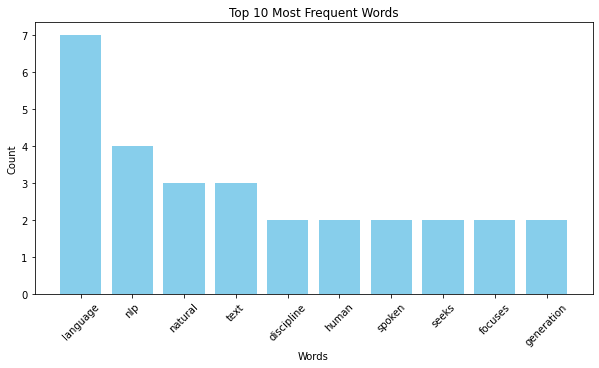

In [ ]:
words, counts = zip(*word_freq.most_common(10))
plt.figure(figsize=(10,5))
plt.bar(words, counts, color='skyblue')
plt.xticks(rotation=45)
plt.title("Top 10 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Count")
plt.show()